# Week 4 Day 2 Lab


### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [5]:
import pandas as pd

In [29]:
df = pd.DataFrame({'values': np.random.uniform(0, 1, size=300)})
df.to_csv("Random_data.csv", index=False)
print(df)

       values
0    0.678411
1    0.549812
2    0.279475
3    0.873623
4    0.922638
..        ...
295  0.573005
296  0.229969
297  0.143190
298  0.563597
299  0.640526

[300 rows x 1 columns]


### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

In [9]:
x = [100,201,303,405,503]
np.mean(x)

np.float64(302.4)

302.4


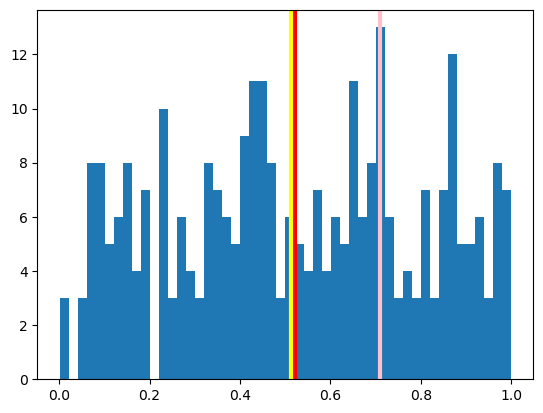

In [65]:
def mean(input):
    return(sum(input) / len(input))
x = [100,201,303,405,503]
print(mean(x))

def median(data):
    data = sorted(data)
    if len(data)%2 == 0:
        return (data[len(data)//2] + (data[len(data)//2 - 1]))/2
    else:
        return data[len(data)//2]
def mode(input):
    return max(input.value_counts())
    

#2 

dataset = pd.read_csv("Random_data.csv")

#3
 #imported from lecture notes for mode calculation
counts, bins = np.histogram(dataset, bins=50)    
mode = (bins[np.argmax(counts)] + bins[np.argmax(counts)+1])/2

plt.hist(dataset, bins=50)
plt.axvline(np.mean(dataset), color='red', linewidth=3)
plt.axvline(np.median(dataset), color='yellow', linewidth=3)
plt.axvline(mode, color='pink', linewidth=3)

#4 The mean and median are pretty close together while the mode is not as close

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

TypeError: unsupported operand type(s) for +: 'int' and 'str'

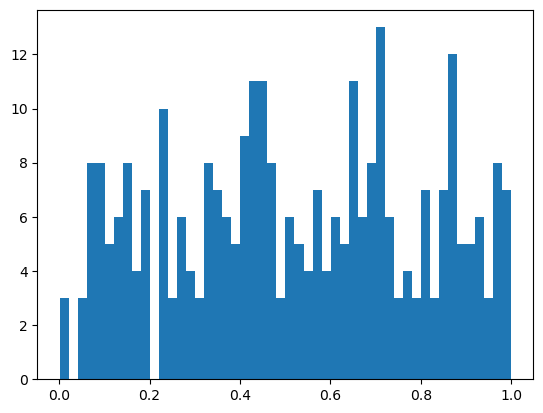

In [69]:
dataset = pd.read_csv("Random_data.csv")
def mad(dataset):
    length = len(dataset)
    mean = sum(dataset) / length
    return sum(abs(i-mean) for i in dataset) / length
def variance(dataset):
    length = len(dataset)
    mean = sum(dataset) / length
    return sum((i-mean)**2 for i in dataset) / length
def standard_deviation(dataset):
    return variance(dataset)**0.5

plt.hist(dataset, bins=50)
plt.axvline(np.mean(dataset) + variance(dataset), color='red')
plt.axvline(np.mean(dataset) - variance(dataset), color='red')